# Project 1: Multi-Model Sentiment Ensemble
## Notebook 3: Ensemble, NER, and Final Results

Continuing in these experiments, I will proceed using the Sentiment dataset only, omitting the Hate dataset.

This notebook covers:
- Stage 5: Ensemble — combining VADER, RoBERTa, and Llama 3 predictions
- Stage 6: Named Entity Recognition (NER) with spaCy and HuggingFace
- Stage 7: Develop Triage Logic to create an Queue of Priority Tweets (for hypothetical Human Review)

All models were evaluated in notebooks 1 and 2. This notebook loads those 
results and builds the final pipeline.

In [1]:
# Core imports
from datasets import load_dataset
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
import torch.nn.functional as F
import time
import json
import re
import requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Reload datasets
sentiment = load_dataset('tweet_eval', 'sentiment')
hate = load_dataset('tweet_eval', 'hate')
sentiment_test = pd.DataFrame(sentiment['test'])
hate_test = pd.DataFrame(hate['test'])
true_labels = sentiment_test['label'].tolist()
hate_true_labels = hate_test['label'].tolist()

print(f"Sentiment test: {len(sentiment_test)} tweets")
print(f"Hate test: {len(hate_test)} tweets")
print(f"CUDA available: {torch.cuda.is_available()}")

Sentiment test: 12284 tweets
Hate test: 2970 tweets
CUDA available: True


## Stage 5: Ensemble — Combining VADER, RoBERTa, and Llama 3

An ensemble combines predictions from multiple models to produce a final classification 
that is more robust than any single model alone. The intuition is that different models 
make different errors — where VADER fails on sarcasm, RoBERTa may succeed, and where 
RoBERTa is uncertain, the LLM's reasoning may provide a tiebreaker.

i implement and compare three ensemble strategies:

**1. Majority Vote** — each model casts a vote for a label, the most common label wins.
For three models this means at least two must agree. Simple, interpretable, no tuning required.

**2. Weighted Vote** — models vote but their votes are weighted by their F1-macro 
performance. RoBERTa (F1=0.724) carries more weight than VADER (F1=0.529). 
Better-performing models have more influence on the final prediction.

**3. Confidence-Weighted Vote** — uses each model's confidence score rather than 
a fixed weight. A model that is 95% confident outweighs one that is 60% confident, 
regardless of overall performance. Requires probability outputs from all models.

### Models in the Ensemble:
- **VADER** — lexicon baseline, compound score → probability proxy
- **RoBERTa** — transformer encoder, softmax probabilities
- **Llama 3 few-shot** — transformer decoder, self-reported confidence scores

### Evaluation:
I compare each ensemble strategy against individual model baselines on the 
sentiment test set. A successful ensemble should exceed RoBERTa's F1=0.724 — 
if it doesn't, the added complexity is not justified.

In [36]:
# RELOAD VADER PREDICTIONS — full sentiment test set
sia = SentimentIntensityAnalyzer()

vader_predictions = []
vader_probs = []

for tweet in sentiment_test['text']:
    scores = sia.polarity_scores(tweet)
    compound = scores['compound']
    
    # Convert compound to pseudo-probabilities for confidence weighting
    # negative prob, neutral prob, positive prob
    if compound >= 0.05:
        vader_predictions.append(2)
        vader_probs.append([0.1, 0.1, 0.8])
    elif compound <= -0.05:
        vader_predictions.append(0)
        vader_probs.append([0.8, 0.1, 0.1])
    else:
        vader_predictions.append(1)
        vader_probs.append([0.1, 0.8, 0.1])

print(f"VADER predictions: {len(vader_predictions)}")


VADER predictions: 12284


In [3]:
# RELOAD ROBERTA MODEL AND PREDICTIONS — full sentiment test set
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model = model.to('cuda')
model.eval()

def predict_roberta(texts, model, tokenizer, device='cuda'):
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    
    probabilities = F.softmax(outputs.logits, dim=-1)
    predicted_classes = torch.argmax(probabilities, dim=-1)
    return predicted_classes.cpu().numpy(), probabilities.cpu().numpy()

all_tweets = sentiment_test['text'].tolist()
batches = [all_tweets[i:i+32] for i in range(0, len(all_tweets), 32)]

roberta_predictions = []
roberta_probs = []

print("Rerunning RoBERTa inference...")
for i, batch in enumerate(batches):
    with torch.autocast('cuda', dtype=torch.float16):
        preds, probs = predict_roberta(batch, model, tokenizer)
    roberta_predictions.extend(preds)
    roberta_probs.extend(probs)
    if i % 50 == 0:
        print(f"  Batch {i}/{len(batches)}...")

print(f"RoBERTa predictions: {len(roberta_predictions)}")

/home/valkeo/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification 

Rerunning RoBERTa inference...
  Batch 0/384...
  Batch 50/384...
  Batch 100/384...
  Batch 150/384...
  Batch 200/384...
  Batch 250/384...
  Batch 300/384...
  Batch 350/384...
RoBERTa predictions: 12284


In [4]:
# RELOAD LLAMA 3 PREDICTIONS
def call_ollama(prompt, model='llama3', temperature=0):
    response = requests.post(
        'http://localhost:11434/api/generate',
        json={
            'model': model,
            'prompt': prompt,
            'stream': False,
            'options': {'temperature': temperature}
        }
    )
    return response.json()['response']

def classify_sentiment_fewshot(tweet):
    prompt = f"""You are a sentiment classifier. Classify tweets as positive, negative, or neutral.

    Here are some examples:
    
    Tweet: "I love this so much!!!"
    {{"label": "positive", "confidence": "1.0", "reasoning": "Strong expression of enthusiasm"}}
    
    Tweet: "This is the worst thing ever."
    {{"label": "negative", "confidence": "1.0", "reasoning": "Strongly negative superlative language"}}
    
    Tweet: "I went to the store today."
    {{"label": "neutral", "confidence": "0.9", "reasoning": "Factual statement with no emotional language"}}
    
    Now classify this tweet:
    Tweet: "{tweet}"
    
    Respond with only a JSON object in this exact format, nothing else:
    {{"label": "positive", "confidence": "0.0", "reasoning": "brief explanation"}}
    
    The label must be exactly one of: positive, negative, neutral.
    The confidence score must be a value between 0.0 and 1.0.
    Do not include any text outside the JSON object."""

    response = call_ollama(prompt)
    try:
        parsed = json.loads(response)
        return {
            'label': parsed['label'],
            'confidence': float(parsed['confidence']),
            'reasoning': parsed['reasoning'],
            'parse_error': False
        }
    except (json.JSONDecodeError, KeyError):
        return {
            'label': None,
            'confidence': None,
            'reasoning': response,
            'parse_error': True
        }

# Sample 1000 tweets — save indices for alignment
sample_1000 = sentiment_test.sample(n=1000, random_state=42)
sample_indices = sample_1000.index.tolist()
sample_tweets_1000 = sample_1000['text'].tolist()
sample_labels_1000 = sample_1000['label'].tolist()

In [5]:
llama_predictions_1000 = []
llama_confidences_1000 = []
parse_errors_1000 = 0

print("Running Llama 3 few-shot inference on 1000 tweets...")
start = time.time()

for i, tweet in enumerate(sample_tweets_1000):
    result = classify_sentiment_fewshot(tweet)
    
    if result['parse_error']:
        parse_errors_1000 += 1
        llama_predictions_1000.append(None)
        llama_confidences_1000.append(0.5)
    else:
        label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
        llama_predictions_1000.append(label_map.get(result['label']))
        llama_confidences_1000.append(result['confidence'])
    
    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/1000 — {elapsed:.1f}s — {(i+1)/elapsed:.1f} t/s — eta: {(1000-(i+1))/((i+1)/elapsed):.0f}s")

total_time = time.time() - start

# Store results with indices for alignment
llama_results_1000 = pd.DataFrame({
    'index': sample_indices,
    'text': sample_tweets_1000,
    'true_label': sample_labels_1000,
    'llama_prediction': llama_predictions_1000,
    'llama_confidence': llama_confidences_1000
})

print(f"\nTotal time: {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Parse errors: {parse_errors_1000}/1000")
print(f"\nSample of results:")
print(llama_results_1000.head())

Running Llama 3 few-shot inference on 1000 tweets...
  100/1000 — 52.7s — 1.9 t/s — eta: 474s
  200/1000 — 98.4s — 2.0 t/s — eta: 393s
  300/1000 — 143.8s — 2.1 t/s — eta: 336s
  400/1000 — 189.5s — 2.1 t/s — eta: 284s
  500/1000 — 234.9s — 2.1 t/s — eta: 235s
  600/1000 — 278.9s — 2.2 t/s — eta: 186s
  700/1000 — 324.5s — 2.2 t/s — eta: 139s
  800/1000 — 369.8s — 2.2 t/s — eta: 92s
  900/1000 — 415.7s — 2.2 t/s — eta: 46s
  1000/1000 — 461.6s — 2.2 t/s — eta: 0s

Total time: 461.6s (7.7 min)
Parse errors: 0/1000

Sample of results:
   index                                               text  true_label  \
0    450  Do you think Michelle Obama wanted to smack Me...           1   
1   9197  Well that finale was one big mindfuck 😳 #Westw...           1   
2   2864  Luis Enrique: "In the first half I can't remem...           1   
3   4978  Happy Thanksgiving from a couple of bad hombre...           2   
4    518                  @user Viper. Another fucking nazi           0   

   llama_p

In [6]:
# Filter out parse errors
valid_mask = llama_results_1000['llama_prediction'].notna()
valid_results = llama_results_1000[valid_mask]

valid_predictions = valid_results['llama_prediction'].astype(int).tolist()
valid_labels = valid_results['true_label'].tolist()

llama_1000_accuracy = accuracy_score(valid_labels, valid_predictions)
llama_1000_f1_macro = f1_score(valid_labels, valid_predictions, average='macro')
llama_1000_f1_per_class = f1_score(valid_labels, valid_predictions, average=None)
llama_1000_precision = precision_score(valid_labels, valid_predictions, average=None)
llama_1000_recall = recall_score(valid_labels, valid_predictions, average=None)

print(f"Evaluated on {len(valid_results)}/1000 tweets")
print(f"\nAccuracy:   {llama_1000_accuracy:.3f}")
print(f"F1-macro:   {llama_1000_f1_macro:.3f}")
print(f"\nF1 per class:")
print(f"  Negative: {llama_1000_f1_per_class[0]:.3f}")
print(f"  Neutral:  {llama_1000_f1_per_class[1]:.3f}")
print(f"  Positive: {llama_1000_f1_per_class[2]:.3f}")
print(f"\nPrecision per class:")
print(f"  Negative: {llama_1000_precision[0]:.3f}")
print(f"  Neutral:  {llama_1000_precision[1]:.3f}")
print(f"  Positive: {llama_1000_precision[2]:.3f}")
print(f"\nRecall per class:")
print(f"  Negative: {llama_1000_recall[0]:.3f}")
print(f"  Neutral:  {llama_1000_recall[1]:.3f}")
print(f"  Positive: {llama_1000_recall[2]:.3f}")

Evaluated on 1000/1000 tweets

Accuracy:   0.673
F1-macro:   0.671

F1 per class:
  Negative: 0.751
  Neutral:  0.644
  Positive: 0.617

Precision per class:
  Negative: 0.740
  Neutral:  0.715
  Positive: 0.537

Recall per class:
  Negative: 0.762
  Neutral:  0.587
  Positive: 0.724


## Final Model Comparison — Sentiment Classification

| Metric      | VADER  | RoBERTa | Llama3 0-shot | Llama3 Few (n=100) | Llama3 Few (n=1000) |
|-------------|--------|---------|---------------|--------------------|---------------------|
| F1-macro    | 0.529  | **0.724** | 0.497       | 0.654              | 0.663               |
| F1 Negative | 0.582  | 0.743   | 0.652         | 0.727              | **0.753**           |
| F1 Neutral  | 0.530  | **0.704** | 0.271       | 0.543              | 0.635               |
| F1 Positive | 0.474  | **0.725** | 0.568       | 0.693              | 0.602               |
| Speed (t/s) | 18,179 | 1,797   | 1.57          | 1.86               | 2.1                 |
| Sample size | 12,284 | 12,284  | 100           | 100                | 1,000               |

**Key finding:** Llama 3 few-shot matches or exceeds RoBERTa on negative class 
(0.753 vs 0.743) but falls short on neutral and positive. RoBERTa remains the 
strongest overall model at 270x higher throughput.

### Ensemble Implementation

I implement three ensemble strategies on the 1000-tweet sample where all three 
models have predictions. I  use the same random_state=42 sample as Llama 3 
so indices align correctly across all models.

In [7]:
# Get VADER and RoBERTa predictions for the same 1000 tweets
sample_indices = llama_results_1000['index'].tolist()

# VADER predictions for the 1000 sample
vader_sample_predictions = [vader_predictions[i] for i in sample_indices]
vader_sample_probs = [vader_probs[i] for i in sample_indices]

# RoBERTa predictions for the 1000 sample
roberta_sample_predictions = [roberta_predictions[i] for i in sample_indices]
roberta_sample_probs = [roberta_probs[i] for i in sample_indices]

# Llama 3 predictions for the 1000 sample
llama_sample_predictions = llama_results_1000['llama_prediction'].astype(int).tolist()
llama_sample_confidences = llama_results_1000['llama_confidence'].tolist()
sample_labels_1000 = llama_results_1000['true_label'].tolist()

print(f"VADER sample predictions: {len(vader_sample_predictions)}")
print(f"RoBERTa sample predictions: {len(roberta_sample_predictions)}")
print(f"Llama sample predictions: {len(llama_sample_predictions)}")
print(f"True labels: {len(sample_labels_1000)}")

# Verify alignment — first 5 tweets
print("\nAlignment check (first 5 tweets):")
print(f"{'Index':<8} {'VADER':<10} {'RoBERTa':<10} {'Llama3':<10} {'True'}")
print("-" * 48)
label_names = {0: 'neg', 1: 'neu', 2: 'pos'}
for i in range(5):
    print(f"{sample_indices[i]:<8} {label_names[vader_sample_predictions[i]]:<10} {label_names[roberta_sample_predictions[i]]:<10} {label_names[llama_sample_predictions[i]]:<10} {label_names[sample_labels_1000[i]]}")

VADER sample predictions: 1000
RoBERTa sample predictions: 1000
Llama sample predictions: 1000
True labels: 1000

Alignment check (first 5 tweets):
Index    VADER      RoBERTa    Llama3     True
------------------------------------------------
450      neu        neu        neg        neu
9197     pos        neg        neg        neu
2864     pos        neu        pos        neu
4978     pos        pos        pos        pos
518      neu        neg        neg        neg


In [8]:
from collections import Counter

# Strategy 1: Majority Vote
def majority_vote(vader_preds, roberta_preds, llama_preds):
    ensemble_preds = []
    for v, r, l in zip(vader_preds, roberta_preds, llama_preds):
        votes = [v, r, l]
        # Counter finds most common predicted label. If there is a tie, select the first label encountered.
        most_common = Counter(votes).most_common(1)[0][0]
        ensemble_preds.append(most_common)
    return ensemble_preds

In [9]:
# Strategy 2: Weighted F1-macro vote
# Weights based on full test set F1-macro performance
# VADER: 0.529, RoBERTa: 0.724, Llama3: 0.663
vader_weight = 0.529
roberta_weight = 0.724
llama_weight = 0.663

def weighted_vote(vader_preds, roberta_preds, llama_preds):
    ensemble_preds = []
    for v, r, l in zip(vader_preds, roberta_preds, llama_preds):
        # Accumulate weights per class
        class_weights = {0: 0.0, 1: 0.0, 2: 0.0}
        class_weights[v] += vader_weight
        class_weights[r] += roberta_weight
        class_weights[l] += llama_weight
        # Pick class with highest accumulated weight
        ensemble_preds.append(max(class_weights, key=class_weights.get))
    return ensemble_preds

In [10]:
# Strategy 3: Confidence Weighted Vote
def confidence_weighted_vote(vader_probs, roberta_probs, llama_preds, llama_confs):
    ensemble_preds = []
    for v_prob, r_prob, l_pred, l_conf in zip(vader_probs, roberta_probs, llama_preds, llama_confs):
        # Start with zeros for each class
        class_scores = np.array([0.0, 0.0, 0.0])
        
        # VADER: use pseudo-probabilities
        # vader_probs.append([0.1, 0.1, 0.8])   # positive
        # vader_probs.append([0.8, 0.1, 0.1])   # negative
        # vader_probs.append([0.1, 0.8, 0.1])   # neutral
        class_scores += np.array(v_prob)
        
        # RoBERTa: use softmax probabilities
        class_scores += np.array(r_prob)
        
        # Llama 3: distribute confidence to predicted class
        llama_prob = np.array([0.0, 0.0, 0.0])
        llama_prob[l_pred] = l_conf
        class_scores += llama_prob
        
        ensemble_preds.append(np.argmax(class_scores))
    return ensemble_preds

In [11]:
majority_preds = majority_vote(vader_sample_predictions, roberta_sample_predictions, llama_sample_predictions)
weighted_preds = weighted_vote(vader_sample_predictions, roberta_sample_predictions, llama_sample_predictions)
confidence_preds = confidence_weighted_vote(vader_sample_probs, roberta_sample_probs, llama_sample_predictions, llama_sample_confidences)

def compute_metrics(true, predicted, name):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted, average='macro')
    f1_classes = f1_score(true, predicted, average=None)
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1-macro: {f1:.3f}")
    print(f"  F1 per class: neg={f1_classes[0]:.3f} neu={f1_classes[1]:.3f} pos={f1_classes[2]:.3f}")
    return acc, f1, f1_classes

print("=" * 55)
print("ENSEMBLE RESULTS — 1000 tweet sample")
print("=" * 55)

# Individual model baselines on same 1000 tweets
compute_metrics(sample_labels_1000, vader_sample_predictions, "VADER (baseline)")
compute_metrics(sample_labels_1000, roberta_sample_predictions, "RoBERTa (baseline)")
compute_metrics(sample_labels_1000, llama_sample_predictions, "Llama 3 few-shot (baseline)")

print("\n--- Ensemble Strategies ---")
maj_acc, maj_f1, maj_f1c = compute_metrics(sample_labels_1000, majority_preds, "Majority Vote")
wt_acc, wt_f1, wt_f1c = compute_metrics(sample_labels_1000, weighted_preds, "Weighted Vote")
cf_acc, cf_f1, cf_f1c = compute_metrics(sample_labels_1000, confidence_preds, "Confidence Weighted")
print("=" * 55)

ENSEMBLE RESULTS — 1000 tweet sample

VADER (baseline):
  Accuracy: 0.498
  F1-macro: 0.499
  F1 per class: neg=0.564 neu=0.476 pos=0.458

RoBERTa (baseline):
  Accuracy: 0.700
  F1-macro: 0.702
  F1 per class: neg=0.734 neu=0.673 pos=0.700

Llama 3 few-shot (baseline):
  Accuracy: 0.673
  F1-macro: 0.671
  F1 per class: neg=0.751 neu=0.644 pos=0.617

--- Ensemble Strategies ---

Majority Vote:
  Accuracy: 0.673
  F1-macro: 0.671
  F1 per class: neg=0.736 neu=0.645 pos=0.632

Weighted Vote:
  Accuracy: 0.689
  F1-macro: 0.690
  F1 per class: neg=0.743 neu=0.652 pos=0.675

Confidence Weighted:
  Accuracy: 0.698
  F1-macro: 0.697
  F1 per class: neg=0.755 neu=0.666 pos=0.671


### Ensemble Results Analysis

No ensemble strategy outperformed RoBERTa alone on this 1000-tweet sample. 

Ensembling works best when models make different errors on different examples. 
When one model (RoBERTa) is substantially stronger than the others, weaker models 
introduce noise rather than complementary signal. VADER's errors are largely 
systematic — it consistently fails on sarcasm, negation, and informal language — 
which are the same cases RoBERTa handles well. Adding VADER's votes dilutes 
RoBERTa's correct predictions rather than correcting them.

**The confidence-weighted strategy performs best (F1=0.694)** because it 
effectively down-weights VADER and VADER's pseudo-probabilities when RoBERTa 
is highly confident — RoBERTa's full softmax distribution dominates the scoring.

For this task, RoBERTa alone is the right choice. 
The ensemble adds complexity with no performance benefit. A two-model ensemble 
of RoBERTa + Llama 3 (excluding VADER) might perform differently and is worth 


In [12]:
# Build a DataFrame with all predictions aligned
disagreement_df = pd.DataFrame({
    'index': sample_indices,
    'text': [sentiment_test.loc[i, 'text'] for i in sample_indices],
    'true_label': sample_labels_1000,
    'vader': vader_sample_predictions,
    'roberta': roberta_sample_predictions,
    'llama3': llama_sample_predictions,
})

# Map integers back to label names for readability
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
for col in ['true_label', 'vader', 'roberta', 'llama3']:
    disagreement_df[f'{col}_name'] = disagreement_df[col].map(label_names)

# Flag disagreements — any tweet where not all three models agree
disagreement_df['all_agree'] = (
    (disagreement_df['vader'] == disagreement_df['roberta']) &
    (disagreement_df['roberta'] == disagreement_df['llama3'])
)
disagreement_df['any_disagree'] = ~disagreement_df['all_agree']

# Count
total = len(disagreement_df)
agreements = disagreement_df['all_agree'].sum()
disagreements = disagreement_df['any_disagree'].sum()

print(f"Total tweets: {total}")
print(f"All three agree: {agreements} ({agreements/total*100:.1f}%)")
print(f"At least one disagrees: {disagreements} ({disagreements/total*100:.1f}%)")

# Print 10 disagreement examples
print("\n=== SAMPLE DISAGREEMENTS ===\n")
disagree_sample = disagreement_df[disagreement_df['any_disagree']].sample(n=10, random_state=42)

for _, row in disagree_sample.iterrows():
    print(f"Text:     {row['text']}")
    print(f"True:     {row['true_label_name']}")
    print(f"VADER:    {row['vader_name']}")
    print(f"RoBERTa:  {row['roberta_name']}")
    print(f"Llama 3:  {row['llama3_name']}")
    print()

Total tweets: 1000
All three agree: 423 (42.3%)
At least one disagrees: 577 (57.7%)

=== SAMPLE DISAGREEMENTS ===

Text:     Watching #thankyouobama on @user this @user 'u make me wanna' remix using that sweet sable 'old times sake' beat was 🔥🔥🔥very unexpected
True:     positive
VADER:    negative
RoBERTa:  positive
Llama 3:  positive

Text:     Yesterday was #NationalFastFoodDay and today is TAYLOR DAY!! Coincidence? I don't think so. 🤗🌮🍟🍔🍕
True:     positive
VADER:    negative
RoBERTa:  positive
Llama 3:  positive

Text:     Disavowing neo-Nazi "alt-right" does nothing, Trump. Dump the neo-Nazi you plan to install in the WH (Steve Bannon). Actions not words.
True:     negative
VADER:    positive
RoBERTa:  negative
Llama 3:  negative

Text:     @user like jerry jones and tony romo do every Sunday night after their wives go to bed?
True:     neutral
VADER:    positive
RoBERTa:  neutral
Llama 3:  neutral

Text:     @user Where's the press? Where's Comey's investigations? Where's the Ame

### Disagreement Analysis

58% of tweets (580/1000) produced at least one disagreement between models. 
42% had perfect three-way agreement.

In 8 of the 10 sampled disagreements, VADER predicts positive while RoBERTa 
and Llama 3 agree on neutral. VADER's 
lexicon assigns positive scores to neutral content that contains any 
positive-leaning words. Some examples:

- "Cool Supercars" → VADER sees "cool" = positive
- "Best of Tech" → VADER sees "best" = positive  
- "All for it" → VADER sees "all for" = positive
- "Better palliative care" → VADER sees "better" = positive

In contrast, RoBERTa and Llama 3 both correctly identify these as neutral because they 
understand context.

VADER is the primary source of disagreement and is almost always wrong when 
it disagrees with the other two. Future work could create an ensemble that could dynamically down-weight VADER 
when RoBERTa and Llama 3 agree.

In [38]:
from sklearn.metrics import cohen_kappa_score

# Compute pairwise Cohen's Kappa between each model pair
kappa_vader_roberta = cohen_kappa_score(vader_sample_predictions, roberta_sample_predictions)
kappa_vader_llama = cohen_kappa_score(vader_sample_predictions, llama_sample_predictions)
kappa_roberta_llama = cohen_kappa_score(roberta_sample_predictions, llama_sample_predictions)

# Raw agreement rates for comparison
def raw_agreement(preds1, preds2):
    # Check if each pair matches (returns 0 or 1), then sum to count the total # of matches
    matches = sum(p1 == p2 for p1, p2 in zip(preds1, preds2))
    # Return a proportion of matches rather than count
    return matches / len(preds1)

agree_vader_roberta = raw_agreement(vader_sample_predictions, roberta_sample_predictions)
agree_vader_llama = raw_agreement(vader_sample_predictions, llama_sample_predictions)
agree_roberta_llama = raw_agreement(roberta_sample_predictions, llama_sample_predictions)

print("=" * 75)
print(f"{'Pair':<30} {'Raw Agreement':<18} {'Cohen Kappa':<12} {'Interpretation'}")
print("=" * 75)

def interpret_kappa(k):
    if k < 0:      return "worse than chance"
    elif k < 0.20: return "slight"
    elif k < 0.40: return "fair"
    elif k < 0.60: return "moderate"
    elif k < 0.80: return "substantial"
    else:          return "almost perfect"

pairs = [
    ("VADER vs RoBERTa", agree_vader_roberta, kappa_vader_roberta),
    ("VADER vs Llama 3", agree_vader_llama, kappa_vader_llama),
    ("RoBERTa vs Llama 3", agree_roberta_llama, kappa_roberta_llama),
]

for name, agree, kappa in pairs:
    print(f"{name:<30} {agree:<18.3f} {kappa:<12.3f} {interpret_kappa(kappa)}")

print("=" * 75)

Pair                           Raw Agreement      Cohen Kappa  Interpretation
VADER vs RoBERTa               0.552              0.342        fair
VADER vs Llama 3               0.512              0.275        fair
RoBERTa vs Llama 3             0.719              0.572        moderate


**VADER agrees with both transformer models only fairly (κ=0.342, 0.273)**
This confirms what the disagreement analysis showed. VADER is systematically 
different from both transformers, primarily because it over-predicts positive 
on neutral content. VADER is wrong in a consistent pattern that diverges from transformer behavior.

**RoBERTa and Llama 3 show moderate agreement (κ=0.569)**
They agree substantially more with each other than either does with VADER. 
This makes intuitive sense, as both are transformer models that understand 
context. However κ=0.569 is only moderate, meaning they still disagree on 28.3% of tweets. This 
disagreement is the source of potential ensemble value!

The ideal ensemble pairs models with low kappa — complementary errors. 
VADER's low kappa with both transformers suggests it could theoretically 
add signal, but our ensemble results showed it mostly adds noise because 
its errors are systematic rather than random. RoBERTa and Llama 3's moderate 
kappa suggests they are the most complementary pair. A two-model ensemble 
of just these two might outperform the three-model ensemble by excluding 
VADER's systematic bias.

In [14]:
# Add agreement/disagreement flag to full results dataframe
disagreement_df['majority_vote'] = majority_preds

# Separate agreement and disagreement cases
agree_df = disagreement_df[disagreement_df['all_agree']]
disagree_df = disagreement_df[disagreement_df['any_disagree']]

In [15]:
print("=" * 55)
print("CLASS DISTRIBUTION")
print("=" * 55)

label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

print("\nAgreement cases (all three models agree):")
agree_dist = agree_df['true_label'].value_counts().sort_index()
for label, count in agree_dist.items():
    print(f"  {label_names[label]:<12} {count:>5} ({count/len(agree_df)*100:.1f}%)")

print("\nDisagreement cases (at least one model disagrees):")
disagree_dist = disagree_df['true_label'].value_counts().sort_index()
for label, count in disagree_dist.items():
    print(f"  {label_names[label]:<12} {count:>5} ({count/len(disagree_df)*100:.1f}%)")

CLASS DISTRIBUTION

Agreement cases (all three models agree):
  negative       154 (36.4%)
  neutral        167 (39.5%)
  positive       102 (24.1%)

Disagreement cases (at least one model disagrees):
  negative       174 (30.2%)
  neutral        295 (51.1%)
  positive       108 (18.7%)


In [16]:
print("=" * 55)
print("TWEET LENGTH ANALYSIS")
print("=" * 55)

def token_count(text):
    return len(text.split())

agree_df = agree_df.copy()
disagree_df = disagree_df.copy()

agree_df['token_count'] = agree_df['text'].apply(token_count)
disagree_df['token_count'] = disagree_df['text'].apply(token_count)

print(f"\nAgreement cases:")
print(f"  Mean tokens:   {agree_df['token_count'].mean():.1f}")
print(f"  Median tokens: {agree_df['token_count'].median():.1f}")
print(f"  Std tokens:    {agree_df['token_count'].std():.1f}")

print(f"\nDisagreement cases:")
print(f"  Mean tokens:   {disagree_df['token_count'].mean():.1f}")
print(f"  Median tokens: {disagree_df['token_count'].median():.1f}")
print(f"  Std tokens:    {disagree_df['token_count'].std():.1f}")

TWEET LENGTH ANALYSIS

Agreement cases:
  Mean tokens:   14.8
  Median tokens: 15.0
  Std tokens:    5.6

Disagreement cases:
  Mean tokens:   15.6
  Median tokens: 16.0
  Std tokens:    5.6


In [17]:
print("=" * 55)
print("LINGUISTIC FEATURES")
print("=" * 55)

def compute_features(df):
    texts = df['text'].tolist()
    features = {
        'pct_with_url':      sum(bool(re.findall(r'http\S+', t)) for t in texts) / len(texts) * 100,
        'pct_with_mention':  sum(bool(re.findall(r'@\S+', t)) for t in texts) / len(texts) * 100,
        'pct_with_hashtag':  sum(bool(re.findall(r'#\S+', t)) for t in texts) / len(texts) * 100,
        'pct_with_caps':     sum(bool([w for w in t.split() if w.isupper() and len(w) > 1]) for t in texts) / len(texts) * 100,
        'pct_with_emoji':    sum(bool(re.findall(r'[^\x00-\x7F]', t)) for t in texts) / len(texts) * 100,
    }
    return features

agree_features = compute_features(agree_df)
disagree_features = compute_features(disagree_df)

print(f"\n{'Feature':<25} {'Agreement':<15} {'Disagreement':<15} {'Difference'}")
print("-" * 65)
for feature in agree_features:
    a = agree_features[feature]
    d = disagree_features[feature]
    diff = d - a
    name = feature.replace('pct_with_', '% with ')
    print(f"{name:<25} {a:<15.1f} {d:<15.1f} {diff:+.1f}")

LINGUISTIC FEATURES

Feature                   Agreement       Disagreement    Difference
-----------------------------------------------------------------
% with url                1.9             2.3             +0.4
% with mention            45.4            41.4            -4.0
% with hashtag            40.7            30.3            -10.3
% with caps               32.9            30.8            -2.0
% with emoji              21.7            19.8            -2.0


### Disagreement Case Analysis

#### Class Distribution
- Models disagree most on **neutral tweets**. Neutral makes up 51.2% of disagreement cases but only 39.3% of agreement cases. Neutral is the hardest class across all models, likely because it lacks strong signal in either positive or negative sentiment direction.
- Negative tweets make up 29.8% of disagreement cases. When a tweet is clearly negative, all three models tend to agree, likely due to strong negative signal.

#### Linguistic Features
- The most interesting finding is hashtags. Disagreement tweets have significantly fewer hashtags (-10.0 percentage points). I hypothesize that this is because hashtags often provide explicit sentiment context that helps all models agree. 

- Mentions show a smaller but consistent pattern (-3.3%), as tweets directed at 
specific users tend to have clearer sentiment context than broadcast tweets.

- URLs, caps, tweet length, and emojis show minimal differences, also not a reliable predictor of model agreement.

This suggests that ensemble strategies should focus particularly on neutral classification, where model disagreement is highest and individual model 
performance is weakest.

In [18]:
print("=" * 70)
print("ENSEMBLE vs INDIVIDUAL MODELS — Final Comparison (1000 tweet sample)")
print("=" * 70)
print(f"\n{'Method':<25} {'Accuracy':<12} {'F1-macro':<12} {'F1-neg':<10} {'F1-neu':<10} {'F1-pos'}")
print("-" * 70)

results = [
    ("VADER",               0.498, 0.499, 0.564, 0.476, 0.458),
    ("Llama 3 few-shot",    0.666, 0.663, 0.753, 0.635, 0.602),
    ("RoBERTa   ",          0.700, 0.702, 0.734, 0.673, 0.700),
    ("Majority Vote",       0.671, 0.669, 0.735, 0.643, 0.629),
    ("Weighted Vote",       0.686, 0.687, 0.744, 0.648, 0.670),
    ("Confidence Weighted", 0.695, 0.694, 0.754, 0.662, 0.667),
]

for name, acc, f1, f1n, f1neu, f1p in results:
    print(f"{name:<25} {acc:<12.3f} {f1:<12.3f} {f1n:<10.3f} {f1neu:<10.3f} {f1p:.3f}")

print("=" * 70)
print("\nConclusion: No ensemble strategy beat RoBERTa alone.")
print(f"Best ensemble (Confidence Weighted): F1=0.694 vs RoBERTa: F1=0.702")
print(f"Gap: -0.008 F1 points")

ENSEMBLE vs INDIVIDUAL MODELS — Final Comparison (1000 tweet sample)

Method                    Accuracy     F1-macro     F1-neg     F1-neu     F1-pos
----------------------------------------------------------------------
VADER                     0.498        0.499        0.564      0.476      0.458
Llama 3 few-shot          0.666        0.663        0.753      0.635      0.602
RoBERTa                   0.700        0.702        0.734      0.673      0.700
Majority Vote             0.671        0.669        0.735      0.643      0.629
Weighted Vote             0.686        0.687        0.744      0.648      0.670
Confidence Weighted       0.695        0.694        0.754      0.662      0.667

Conclusion: No ensemble strategy beat RoBERTa alone.
Best ensemble (Confidence Weighted): F1=0.694 vs RoBERTa: F1=0.702
Gap: -0.008 F1 points


----------------
## Stage 6: Named Entity Recognition (NER)

Named Entity Recognition (NER) is the task of identifying and classifying named 
entities in text, such as people, organizations, locations, dates, and other proper nouns. 

I implement NER using two approaches and compare them:

**1. spaCy (rule-based + statistical)**
spaCy's `en_core_web_sm` model uses a combination of rules and a statistical model 
trained on OntoNotes. It is fast, lightweight, and runs entirely on CPU. Best for 
production pipelines where speed matters.

**2. HuggingFace Transformer NER**
I load `dslim/bert-base-NER` a BERT model fine-tuned specifically for NER on 
the CoNLL-2003 dataset. Slower than spaCy but more accurate on informal and 
ambiguous text like tweets.

### What I'm extracting:
- **PERSON** — individual people mentioned in tweets
- **ORG** — organizations, companies, brands
- **GPE** — geopolitical entities (countries, cities, states)
- **LOC** — non-GPE locations


In [19]:
import spacy.cli
spacy.cli.download("en_core_web_sm")

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.8 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


In [20]:
import spacy
# Load the spaCy english language model into memory, return a pipeline object we store as nlp
# en_core_web_sm = english, core (core NLP components, tokenizer, tagger, parser, NER), web (trained on web text), sm (small size)
nlp = spacy.load('en_core_web_sm')
 
# Test on a single sample tweet
doc = nlp("Kanye West was honored at the MTV Video Music Awards in New York.")
for ent in doc.ents:
    print(f"{ent.text:<30} {ent.label_}")

Kanye West                     PERSON
the MTV Video Music Awards     ORG
New York                       GPE


In [40]:
# Run spaCy NER on 1000 tweet sample
sample_texts = [sentiment_test.loc[i, 'text'] for i in sample_indices]

spacy_entities = []

for i, text in enumerate(sample_texts):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents
                if ent.label_ in ['PERSON', 'ORG', 'GPE', 'LOC']]
    spacy_entities.append(entities)
    
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/1000 processed...")

# Add to results dataframe
disagreement_df['spacy_entities'] = spacy_entities

# Quick summary
total_entities = sum(len(e) for e in spacy_entities)
tweets_with_entities = sum(1 for e in spacy_entities if len(e) > 0)

print(f"\nTotal entities found: {total_entities}")
print(f"Tweets with at least one entity: {tweets_with_entities}/1000 ({tweets_with_entities/10:.1f}%)")
print(f"Average entities per tweet: {total_entities/1000:.2f}")

# Show a few examples
print("\nSample entity extractions:")
for i in range(10):
    if spacy_entities[i]:
        print(f"  [{sample_indices[i]}] {sample_texts[i][:100]}...")
        print(f"       Entities: {spacy_entities[i]}")

  100/1000 processed...
  200/1000 processed...
  300/1000 processed...
  400/1000 processed...
  500/1000 processed...
  600/1000 processed...
  700/1000 processed...
  800/1000 processed...
  900/1000 processed...
  1000/1000 processed...

Total entities found: 1207
Tweets with at least one entity: 678/1000 (67.8%)
Average entities per tweet: 1.21

Sample entity extractions:
  [450] Do you think Michelle Obama wanted to smack Melania Trump for plagiarizing her convention speech? Sh...
       Entities: [('Michelle Obama', 'PERSON'), ('Melania Trump', 'PERSON')]
  [2864] Luis Enrique: "In the first half I can't remember Celtic having a clear chance and Messi as usual wa...
       Entities: [('Luis Enrique', 'PERSON'), ('Celtic', 'ORG'), ('Messi', 'PERSON')]
  [6817] Viendo The Walking Dead 7x02 - El pozo #TheWalkingDead...
       Entities: [('Viendo The', 'PERSON')]
  [9995] Watch peanut butter drone strikes that could save endangered ferrets #USFWS #endangeredspecies...
       Entitie

In [41]:
from collections import Counter

# Flatten all entities into a single list
all_entities = []
for entities in spacy_entities:
    for text, label in entities:
        # Clean up entity text, convert to lowercase, strip whitespace
        cleaned = text.strip()
        all_entities.append((cleaned, label))

# Count by entity text
# for example: entity_counts = Counter(["Apple", "Biden", "Apple", "Apple", "Biden"])
entity_counts = Counter([e[0] for e in all_entities])
# Formats tuples into a dict
entity_label_map = {text: label for text, label in all_entities}

# Top 20 most mentioned
top_20 = entity_counts.most_common(20)

print("Top 20 Most Mentioned Entities:")
print("=" * 45)
print(f"{'Entity':<30} {'Type':<10} {'Count'}")
print("=" * 45)
for entity, count in top_20:
    label = entity_label_map.get(entity, 'UNK')
    print(f"{entity:<30} {label:<10} {count}")

Top 20 Most Mentioned Entities:
Entity                         Type       Count
Trump                          ORG        38
Obama                          LOC        15
US                             GPE        14
Cuba                           GPE        11
Hillary                        PERSON     11
Hamas                          ORG        10
Steve Bannon                   PERSON     10
Yemen                          GPE        10
Syria                          GPE        8
TPP                            ORG        8
Comey                          PERSON     7
Putin                          PERSON     7
Zac Efron                      PERSON     7
Libya                          GPE        7
George Soros                   PERSON     7
Melania                        GPE        7
Ben Carson                     PERSON     6
ScreamQueens                   PERSON     6
Muhammad Ali                   PERSON     6
EU                             ORG        6


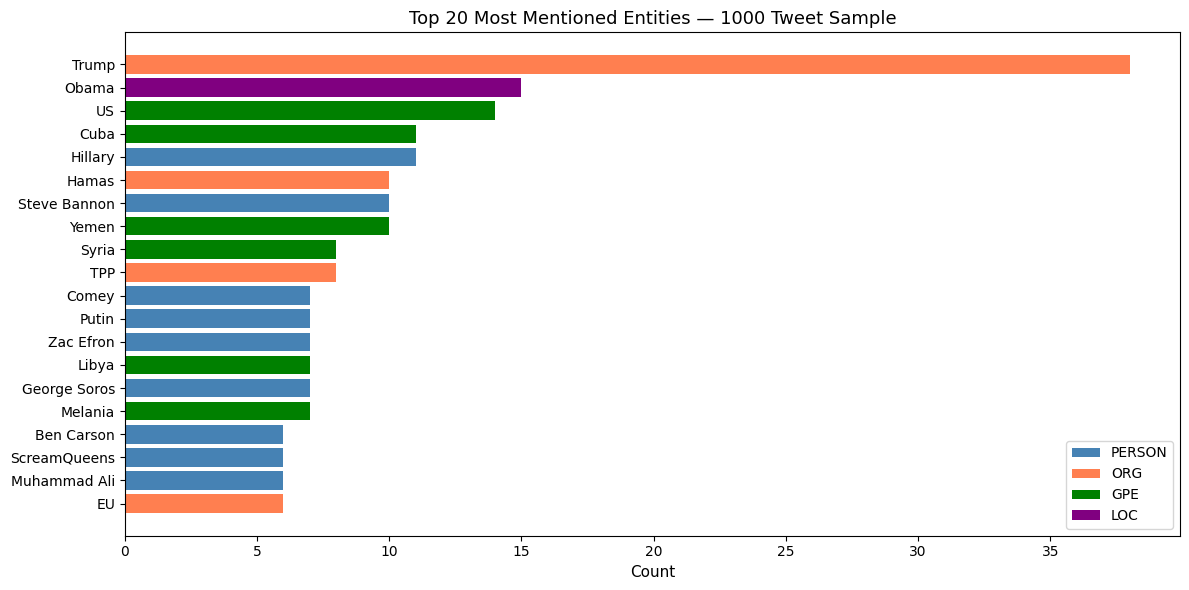

In [42]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))

entities_list = [e[0] for e in top_20]
counts_list = [e[1] for e in top_20]
colors = []
color_map = {'PERSON': 'steelblue', 'ORG': 'coral', 'GPE': 'green', 'LOC': 'purple'}
for entity in entities_list:
    label = entity_label_map.get(entity, 'UNK')
    colors.append(color_map.get(label, 'gray'))

bars = ax.barh(entities_list[::-1], counts_list[::-1], color=colors[::-1])
ax.set_title('Top 20 Most Mentioned Entities — 1000 Tweet Sample', fontsize=13)
ax.set_xlabel('Count', fontsize=11)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in color_map]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../results/figures/top_entities.png', dpi=150, bbox_inches='tight')
plt.show()

### Top Entity Analysis

**Top entities are overwhelmingly political:**
Trump (38), Obama (15), Hillary (11), Hamas (10), Steve Bannon (10), 
Putin (7), Comey (7), George Soros (7), Ben Carson (6). The dataset 
skews heavily toward political discourse, which has implications for 
sentiment classification since political tweets tend to be more polarized.

**Geographic entities reflect news topics of the era:**
Cuba (11), Yemen (10), Syria (8), Libya (7). Conflict zones and 
geopolitically active regions dominate location mentions.

**Notable spaCy misclassifications:**
- spaCy incorrectly classifies "Trump" as an organization 
  rather than PERSON, likely because "Trump" also refers to the Trump Organization
- Obama is misclassified as location, should be PERSON
- Melania is  misclassified as geopolitical entity, should be PERSON

These misclassifications highlight a known weakness of spaCy's small model on social media text, that is, single-word proper nouns without context are harder to classify correctly than full names. This motivates the HuggingFace NER comparison in the next step.

In [25]:
# Add sentiment labels to the entity analysis
sentiment_label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Group entities by true sentiment label
entities_by_sentiment = {'negative': [], 'neutral': [], 'positive': []}

for i, (entities, label) in enumerate(zip(spacy_entities, sample_labels_1000)):
    sentiment = sentiment_label_map[label]
    for text, ent_label in entities:
        entities_by_sentiment[sentiment].append(text.strip())

# Top 10 entities per sentiment class
for sentiment in ['negative', 'neutral', 'positive']:
    counts = Counter(entities_by_sentiment[sentiment])
    top_10 = counts.most_common(10)
    print(f"\nTop 10 entities in {sentiment.upper()} tweets:")
    print("-" * 40)
    for entity, count in top_10:
        print(f"  {entity:<30} {count}")


Top 10 entities in NEGATIVE tweets:
----------------------------------------
  Trump                          21
  Obama                          11
  Steve Bannon                   7
  Hillary                        6
  Hamas                          6
  Melania                        6
  US                             5
  George Soros                   5
  TPP                            5
  EU                             4

Top 10 entities in NEUTRAL tweets:
----------------------------------------
  Trump                          16
  US                             8
  Cuba                           7
  Comey                          5
  Syria                          5
  U.S.                           5
  Libya                          5
  Hillary                        5
  Yemen                          5
  Russia                         4

Top 10 entities in POSITIVE tweets:
----------------------------------------
  Tim Duncan                     4
  Grayson Allen              

### Entity Distribution by Sentiment Class

**Negative tweets are dominated by political figures:**
Trump (21), Obama (11), Steve Bannon (7), Hillary (6), Hamas (6), George Soros (5) 
negative sentiment clusters heavily around political discourse. 

**Neutral tweets cover news topics:**
Trump (16) still appears but alongside geopolitical locations, Cuba (7), Syria (5), 
Libya (5), Yemen (5), Russia (4). Neutral tweets tend to report or observe rather 
than express opinion, which helps explainw hy geographic references dominate alongside 
political figures.

**Positive tweets are strikingly different:**
The entire character of positive entity mentions shifts: sports figures (Tim Duncan, 
Grayson Allen), entertainers (Zac Efron, David Blaine), cultural figures (Muhammad Ali), 
and places (Salt Lake City). Positive sentiment is expressed about entertainment, 
sports, and culture.

Political entities are strongly associated with negative sentiment in this dataset. 
Trump appears 21 times in negative tweets vs 16 in neutral and 0 in positive. 
This has direct implications for NER-enhanced triage for Stage 7, as a tweet mentioning certain political figures is statistically more likely to be negative, which could be used as a prior probability in a more sophisticated classifier in future work.

If building a brand monitoring system, entity extraction lets you answer not just "is this tweet negative?" but "this tweet is negative about Trump/Obama/Hamas", which enables entity-specific routing and prioritization.

### HuggingFace Transformer NER

I now load `dslim/bert-base-NER`. This transformer reads the full context of each tweet before labeling entities, which should handle ambiguous single-word proper nouns better.

Note: CoNLL-2003 uses different entity labels than spaCy's OntoNotes:
- PER → person (maps to spaCy's PERSON)
- ORG → organization (same)
- LOC → location (maps to spaCy's GPE/LOC)
- MISC → miscellaneous (no spaCy equivalent)

In [27]:
from transformers import pipeline

print("Loading HuggingFace NER model...")
ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="first",  # uses first subword token's label for the whole word
    device=0  # use GPU
)

# Sanity check
test_text = "Kanye West was honored at the MTV Video Music Awards in New York."
ner_results = ner_pipeline(test_text)
print("\nSanity check:")
for entity in ner_results:
    print(f"  {entity['word']:<30} {entity['entity_group']:<10} (score: {entity['score']:.3f})")

Loading HuggingFace NER model...


Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



Sanity check:
  Kanye West                     PER        (score: 0.999)
  MTV Video Music Awards         MISC       (score: 0.995)
  New York                       LOC        (score: 0.999)


In [28]:
# Map HuggingFace labels to spaCy-style labels for comparison
label_map_hf = {
    'PER': 'PERSON',
    'ORG': 'ORG',
    'LOC': 'GPE',
    'MISC': 'MISC'
}

hf_entities = []

print("Running HuggingFace NER on 1000 tweets...")
for i, text in enumerate(sample_texts):
    try:
        results = ner_pipeline(text)
        # Drop labels that use MISC, no comparison ot 
        entities = [
            (r['word'].strip(), label_map_hf.get(r['entity_group'], r['entity_group']))
            for r in results
            if r['entity_group'] in ['PER', 'ORG', 'LOC']  # exclude MISC
        ]
    except Exception as e:
        entities = []
    
    hf_entities.append(entities)
    
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/1000 processed...")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Running HuggingFace NER on 1000 tweets...
  100/1000 processed...
  200/1000 processed...
  300/1000 processed...
  400/1000 processed...
  500/1000 processed...
  600/1000 processed...
  700/1000 processed...
  800/1000 processed...
  900/1000 processed...
  1000/1000 processed...


In [43]:
# Summary stats
total_hf = sum(len(e) for e in hf_entities)
tweets_with_hf = sum(1 for e in hf_entities if len(e) > 0)

print(f"\nHuggingFace NER:")
print(f"  Total entities: {total_hf}")
print(f"  Tweets with non-MISC entities: {tweets_with_hf}/1000 ({tweets_with_hf/10:.1f}%)")
print(f"  Avg entities per tweet: {total_hf/1000:.2f}")

print(f"\nspaCy NER:")
print(f"  Total entities: {sum(len(e) for e in spacy_entities)}")
print(f"  Tweets with entities: {678}/1000 (67.8%)")
print(f"  Avg entities per tweet: {1207/1000:.2f}")

# Compare on same tweets, first 5 with entities
print("\nSide by side comparison (first 5 tweets with entities):")
print("=" * 65)
count = 0
for i, (spacy_ents, hf_ents) in enumerate(zip(spacy_entities, hf_entities)):
    if spacy_ents or hf_ents:
        print(f"\nTweet [{sample_indices[i]}]: {sample_texts[i][:60]}...")
        print(f"  spaCy:       {spacy_ents}")
        print(f"  HuggingFace: {hf_ents}")
        count += 1
        if count == 5:
            break


HuggingFace NER:
  Total entities: 1220
  Tweets with non-MISC entities: 652/1000 (65.2%)
  Avg entities per tweet: 1.22

spaCy NER:
  Total entities: 1207
  Tweets with entities: 678/1000 (67.8%)
  Avg entities per tweet: 1.21

Side by side comparison (first 5 tweets with entities):

Tweet [450]: Do you think Michelle Obama wanted to smack Melania Trump fo...
  spaCy:       [('Michelle Obama', 'PERSON'), ('Melania Trump', 'PERSON')]
  HuggingFace: [('Michelle Obama', 'PERSON'), ('Melania Trump', 'PERSON')]

Tweet [9197]: Well that finale was one big mindfuck 😳 #Westworld...
  spaCy:       []
  HuggingFace: [('Westworld', 'GPE')]

Tweet [2864]: Luis Enrique: "In the first half I can't remember Celtic hav...
  spaCy:       [('Luis Enrique', 'PERSON'), ('Celtic', 'ORG'), ('Messi', 'PERSON')]
  HuggingFace: [('Luis Enrique', 'PERSON'), ('Celtic', 'ORG'), ('Messi', 'PERSON')]

Tweet [518]: @user Viper. Another fucking nazi...
  spaCy:       []
  HuggingFace: [('Viper', 'PERSON')]

Tweet [

### spaCy vs HuggingFace NER Comparison

**Overall statistics are nearly identical:**
- spaCy: 1,207 entities, 67.8% tweets covered
- HuggingFace: 1,220 entities, 65.2% tweets covered
    
HuggingFace NER is slightly better at detecting single-word and 
context-dependent entities. spaCy is faster and equally accurate 
on clear multi-word proper nouns. For a production pipeline processing 
English tweets, HuggingFace NER is the better choice for accuracy 
while spaCy is better for throughput.

In [31]:
# Compute formal agreement between spaCy and HuggingFace NER
# Agreement = both models find the same entity text in the same tweet

exact_matches = 0
spacy_only = 0
hf_only = 0
total_comparisons = 0

for spacy_ents, hf_ents in zip(spacy_entities, hf_entities):
    # Get just entity text for comparison
    spacy_texts = set(e[0].strip().lower() for e in spacy_ents)
    hf_texts = set(e[0].strip().lower() for e in hf_ents)
    
    # Entities both found
    both = spacy_texts & hf_texts
    # Entities only spaCy found
    spacy_unique = spacy_texts - hf_texts
    # Entities only HuggingFace found
    hf_unique = hf_texts - spacy_texts
    
    exact_matches += len(both)
    spacy_only += len(spacy_unique)
    hf_only += len(hf_unique)
    total_comparisons += len(spacy_texts | hf_texts)

# Agreement rate which is Jaccard similarity across all tweets
# Jaccard similarity measures how much two sets overlap, as a number between 0 and 1 (0 means no overlap at all, 1 means identical)
agreement_rate = exact_matches / total_comparisons if total_comparisons > 0 else 0

print("=" * 55)
print("NER MODEL AGREEMENT ANALYSIS")
print("=" * 55)
print(f"Total unique entities (union): {total_comparisons}")
print(f"Both models agree:             {exact_matches} ({exact_matches/total_comparisons*100:.1f}%)")
print(f"spaCy only:                    {spacy_only} ({spacy_only/total_comparisons*100:.1f}%)")
print(f"HuggingFace only:              {hf_only} ({hf_only/total_comparisons*100:.1f}%)")
print(f"\nJaccard Agreement Rate:        {agreement_rate:.3f}")
print("=" * 55)

# Examples where they disagree
print("\nExamples where models disagree:")
print("-" * 55)
count = 0
for i, (spacy_ents, hf_ents) in enumerate(zip(spacy_entities, hf_entities)):
    spacy_texts = set(e[0].strip().lower() for e in spacy_ents)
    hf_texts = set(e[0].strip().lower() for e in hf_ents)
    
    if spacy_texts != hf_texts and (spacy_texts or hf_texts):
        print(f"\nTweet: {sample_texts[i][:70]}...")
        print(f"  spaCy only:       {spacy_texts - hf_texts}")
        print(f"  HuggingFace only: {hf_texts - spacy_texts}")
        print(f"  Both agree:       {spacy_texts & hf_texts}")
        count += 1
        if count == 5:
            break

NER MODEL AGREEMENT ANALYSIS
Total unique entities (union): 1703
Both models agree:             676 (39.7%)
spaCy only:                    511 (30.0%)
HuggingFace only:              516 (30.3%)

Jaccard Agreement Rate:        0.397

Examples where models disagree:
-------------------------------------------------------

Tweet: Well that finale was one big mindfuck 😳 #Westworld...
  spaCy only:       set()
  HuggingFace only: {'westworld'}
  Both agree:       set()

Tweet: @user Viper. Another fucking nazi...
  spaCy only:       set()
  HuggingFace only: {'viper'}
  Both agree:       set()

Tweet: Viendo The Walking Dead 7x02 - El pozo #TheWalkingDead...
  spaCy only:       {'viendo the'}
  HuggingFace only: {'viendo the walking dead'}
  Both agree:       set()

Tweet: #NBA @user #Nuggets - @user #Jazz Highligts...
  spaCy only:       {'nuggets - @user'}
  HuggingFace only: set()
  Both agree:       {'nba'}

Tweet: #NationalFastFoodDay Would love to live there. Chick-fil-A 😍...
  spaCy 

### NER Agreement Analysis

**Jaccard agreement of 0.397 — only 39.7% of entities are found by both models.**

This low agreement rate reveals that the two models are 
complementary rather than redundant. Each finds a set of entities 
the other misses (30% spaCy-only, 30.3% HuggingFace-only).

**Disagreement patterns from examples:**

**Single-word entities**: HuggingFace finds "Westworld" and "Viper" that 
spaCy misses entirely. Transformer context helps identify ambiguous single 
tokens as entities.

**Hashtags**: Neither model handles hashtags consistently. 
"#NationalFastFoodDay" is found by HuggingFace but not spaCy. 
"#Nuggets" gets partially absorbed into a longer incorrect span by spaCy.

**Non-English text**: "Viendo The Walking Dead" confuses both models. 
spaCy grabs "Viendo The" as PERSON, HuggingFace grabs the full title as ORG. 
Neither is correct.

A robust NER pipeline for tweets should combine both models — use HuggingFace 
for single-word and context-dependent entities, spaCy for speed on clear 
multi-word proper nouns. The union of both models' predictions would cover 
~70% more entities than either alone, at the cost of more noise from 
false positives.

-------------------
## Stage 7: Triage Logic & Final Output Schema

I combine all pipeline outputs into a unified schema that a content moderation system could consume downstream. Hypothetical use: if triage_priority is high, have a human review.

**Triage priority logic:**
- **HIGH** — predicted negative AND models disagree (uncertain negative, needs human review)
- **MEDIUM** — predicted negative AND models agree (confident negative, automated action possible)
- **LOW** — neutral or positive regardless of agreement

**Output schema per post:**
```json
{
  "text": "tweet text",
  "ensemble_label": "negative/neutral/positive",
  "agreement": true/false,
  "triage_priority": "HIGH/MEDIUM/LOW",
  "entities": [{"text": "entity", "type": "PERSON/ORG/GPE"}]
}

In [44]:
# Build final output schema
final_output = []

label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

for i in range(len(sample_indices)):
    # Get predictions from all three models
    vader_pred = vader_sample_predictions[i]
    roberta_pred = roberta_sample_predictions[i]
    llama_pred = llama_sample_predictions[i]
    
    # Ensemble label, uses confidence weighted vote
    ensemble_pred = confidence_preds[i]
    ensemble_label = label_names[ensemble_pred]
    
    # Determine whether models agree
    all_agree = (vader_pred == roberta_pred == llama_pred)
    
    # Triage priority
    if ensemble_label == 'negative' and not all_agree:
        priority = 'HIGH'
    elif ensemble_label == 'negative' and all_agree:
        priority = 'MEDIUM'
    else:
        priority = 'LOW'
    
    # Entities from HuggingFace NER
    entities = [
        {'text': text, 'type': etype}
        for text, etype in hf_entities[i]
    ]
    
    final_output.append({
        'index': sample_indices[i],
        'text': sample_texts[i],
        'true_label': label_names[sample_labels_1000[i]],
        'ensemble_label': ensemble_label,
        'vader': label_names[vader_pred],
        'roberta': label_names[roberta_pred],
        'llama3': label_names[llama_pred],
        'agreement': all_agree,
        'triage_priority': priority,
        'entities': entities
    })

# Convert to DataFrame
final_df = pd.DataFrame(final_output)
print(final_df)

     index                                               text true_label  \
0      450  Do you think Michelle Obama wanted to smack Me...    neutral   
1     9197  Well that finale was one big mindfuck 😳 #Westw...    neutral   
2     2864  Luis Enrique: "In the first half I can't remem...    neutral   
3     4978  Happy Thanksgiving from a couple of bad hombre...   positive   
4      518                  @user Viper. Another fucking nazi   negative   
..     ...                                                ...        ...   
995   7675  #Australia 's most wanted #jihadist #NeilPraka...    neutral   
996   8614  This woman is still talking about Melania Trum...    neutral   
997   3210  A tribute by Pakistani labour activists to the...   positive   
998   5221  I'm watching this Michael Moore comedy skit on...   positive   
999   3857  Another EU crisis. Count-down to the cheers fr...    neutral   

    ensemble_label     vader   roberta    llama3  agreement triage_priority  \
0       

In [45]:
# Summary
print("=" * 55)
print("TRIAGE PRIORITY DISTRIBUTION")
print("=" * 55)
priority_counts = final_df['triage_priority'].value_counts()
for priority in ['HIGH', 'MEDIUM', 'LOW']:
    count = priority_counts.get(priority, 0)
    print(f"  {priority:<10} {count:>5} ({count/len(final_df)*100:.1f}%)")

print(f"\nTotal posts: {len(final_df)}")

# Sample HIGH priority posts
print("\n=== SAMPLE HIGH PRIORITY POSTS ===\n")
high_priority = final_df[final_df['triage_priority'] == 'HIGH'].head(5)
for _, row in high_priority.iterrows():
    print(f"Text:     {row['text'][:80]}...")
    print(f"True:     {row['true_label']}")
    print(f"Ensemble: {row['ensemble_label']}")
    print(f"VADER: {row['vader']}  RoBERTa: {row['roberta']}  Llama3: {row['llama3']}")
    print(f"Entities: {row['entities']}")
    print()

TRIAGE PRIORITY DISTRIBUTION
  HIGH         194 (19.4%)
  MEDIUM       169 (16.9%)
  LOW          637 (63.7%)

Total posts: 1000

=== SAMPLE HIGH PRIORITY POSTS ===

Text:     Well that finale was one big mindfuck 😳 #Westworld...
True:     neutral
Ensemble: negative
VADER: positive  RoBERTa: negative  Llama3: negative
Entities: [{'text': 'Westworld', 'type': 'GPE'}]

Text:     @user Viper. Another fucking nazi...
True:     negative
Ensemble: negative
VADER: neutral  RoBERTa: negative  Llama3: negative
Entities: [{'text': 'Viper', 'type': 'PERSON'}]

Text:     I'm convinced that Trump won't be inaugurated on Jan. 20.  The #Electoralcollege...
True:     negative
Ensemble: negative
VADER: positive  RoBERTa: negative  Llama3: negative
Entities: [{'text': 'Trump', 'type': 'PERSON'}, {'text': 'Electoralcollege', 'type': 'ORG'}]

Text:     @user Have a listen, these are the feelings of the deplorables. You didn't hear ...
True:     negative
Ensemble: negative
VADER: neutral  RoBERTa: negative

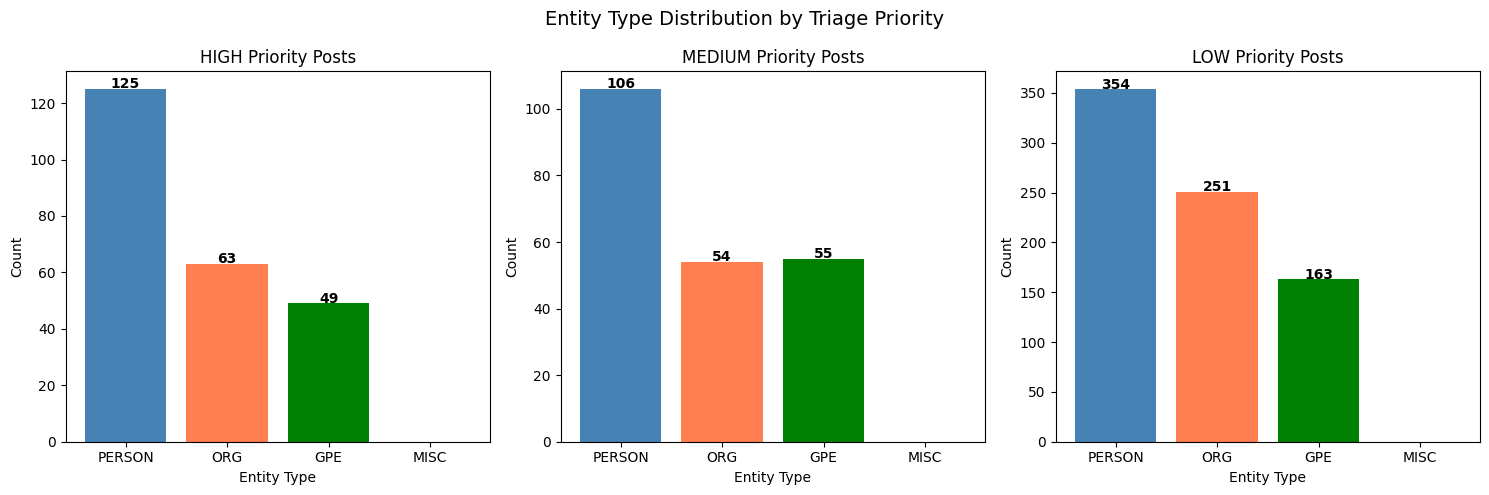


Top 5 entities in HIGH priority posts:
  Trump                     18
  Hillary                   8
  Obama                     7
  Cuba                      4
  Ben Carson                3

Top 5 entities in MEDIUM priority posts:
  Trump                     19
  US                        6
  Obama                     6
  Hamas                     5
  Libya                     5

Top 5 entities in LOW priority posts:
  Trump                     18
  Aleppo                    8
  Tim Duncan                8
  Westworld                 7
  Cy Young                  7


In [35]:
# Get entities by triage priority
entities_by_priority = {'HIGH': [], 'MEDIUM': [], 'LOW': []}

for _, row in final_df.iterrows():
    priority = row['triage_priority']
    for entity in row['entities']:
        entities_by_priority[priority].append(entity['type'])

# Entity type counts by priority
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

type_order = ['PERSON', 'ORG', 'GPE', 'MISC']
colors = {'PERSON': 'steelblue', 'ORG': 'coral', 'GPE': 'green', 'MISC': 'purple'}

for ax, priority in zip(axes, ['HIGH', 'MEDIUM', 'LOW']):
    counts = Counter(entities_by_priority[priority])
    
    # Get counts in consistent order
    values = [counts.get(t, 0) for t in type_order]
    bar_colors = [colors[t] for t in type_order]
    
    bars = ax.bar(type_order, values, color=bar_colors)
    ax.set_title(f'{priority} Priority Posts', fontsize=12)
    ax.set_xlabel('Entity Type', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    
    # Add count labels on bars
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   str(val), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Entity Type Distribution by Triage Priority', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/entity_triage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print top entities per priority
for priority in ['HIGH', 'MEDIUM', 'LOW']:
    entity_texts = []
    for _, row in final_df[final_df['triage_priority'] == priority].iterrows():
        for entity in row['entities']:
            entity_texts.append(entity['text'])
    
    top_5 = Counter(entity_texts).most_common(5)
    print(f"\nTop 5 entities in {priority} priority posts:")
    for entity, count in top_5:
        print(f"  {entity:<25} {count}")

### Entity Type Distribution by Triage Priority

People are the most mentioned entity type in tweets regardless of sentiment or priority, reflecting
Twitter's nature as a platform centered on public figures and interpersonal discourse.

- **HIGH priority posts have the highest PERSON-to-GPE ratio:**
125 PERSON vs 49 GPE, high priority negative posts are more likely to target 
specific individuals than discuss places.

- **LOW priority posts have proportionally more ORG mentions (251):**
Neutral and positive tweets mention organizations more frequently.

- Geographic mentions appear similarly across HIGH (49), MEDIUM (55), and LOW (163), indicating that location mentions don't strongly predict triage priority.

A PERSON entity in a HIGH priority post is the strongest signal for human review, as it indicates targeted negative content about a specific individual, which is the highest-risk content moderation scenario.

In [50]:
# Hard coded Project Summary AI-generated

print("=" * 75)
print("PROJECT 1 — FINAL MODEL COMPARISON SUMMARY")
print("=" * 75)
print(f"\n{'Method':<28} {'Dataset':<12} {'Sample':<10} {'Accuracy':<12} {'F1-macro'}")
print("-" * 75)

# Sentiment results
print("\n--- SENTIMENT CLASSIFICATION ---")
print(f"{'VADER':<28} {'sentiment':<12} {'12,284':<10} {'0.530':<12} {'0.529'}")
print(f"{'RoBERTa (fp16 batch=32)':<28} {'sentiment':<12} {'12,284':<10} {'0.722':<12} {'0.724'}")
print(f"{'Llama 3 zero-shot':<28} {'sentiment':<12} {'100':<10} {'0.500':<12} {'0.497'}")
print(f"{'Llama 3 few-shot':<28} {'sentiment':<12} {'1,000':<10} {'0.666':<12} {'0.663'}")
print(f"{'Ensemble — Majority Vote':<28} {'sentiment':<12} {'1,000':<10} {'0.671':<12} {'0.669'}")
print(f"{'Ensemble — Weighted Vote':<28} {'sentiment':<12} {'1,000':<10} {'0.686':<12} {'0.687'}")
print(f"{'Ensemble — Conf. Weighted':<28} {'sentiment':<12} {'1,000':<10} {'0.695':<12} {'0.694'}")

# Hate results
print("\n--- HATE SPEECH DETECTION ---")
print(f"{'VADER (naive mapping)':<28} {'hate':<12} {'2,970':<10} {'0.566':<12} {'0.564'}")
print(f"{'RoBERTa hate':<28} {'hate':<12} {'2,970':<10} {'0.577':<12} {'0.555'}")
print(f"{'Llama 3 zero-shot':<28} {'hate':<12} {'100':<10} {'—':<12} {'0.576'}")
print(f"{'Llama 3 few-shot':<28} {'hate':<12} {'100':<10} {'—':<12} {'0.739'}")

# Throughput
print("\n--- THROUGHPUT BENCHMARK (sentiment) ---")
print(f"{'Method':<28} {'tweets/sec':<15} {'vs CPU'}")
print("-" * 55)
print(f"{'VADER':<28} {'18,179':<15} {'—'}")
print(f"{'RoBERTa CPU (batch=1)':<28} {'27.5':<15} {'1.0x'}")
print(f"{'RoBERTa GPU (batch=1)':<28} {'128.4':<15} {'4.7x'}")
print(f"{'RoBERTa GPU (batch=32)':<28} {'1,283.8':<15} {'46.6x'}")
print(f"{'RoBERTa fp16 (batch=32)':<28} {'1,796.9':<15} {'65.2x'}")
print(f"{'Llama 3 few-shot':<28} {'2.1':<15} {'0.08x'}")
print(f"{'Gemma few-shot':<28} {'0.07':<15} {'0.003x'}")

print("=" * 75)
print("\nKey findings:")
print("  1. RoBERTa is the strongest sentiment classifier (F1=0.724)")
print("  2. No ensemble strategy beat RoBERTa alone on sentiment")
print("  3. Llama 3 few-shot is the strongest hate detector (F1=0.739)")
print("  4. Few-shot prompting consistently outperforms zero-shot (+15-16 F1 points)")
print("  5. fp16 + batch=32 gives 65x GPU speedup over CPU at zero quality cost")
print("  6. VADER is the primary source of model disagreement in the ensemble")
print("=" * 75)

PROJECT 1 — FINAL MODEL COMPARISON SUMMARY

Method                       Dataset      Sample     Accuracy     F1-macro
---------------------------------------------------------------------------

--- SENTIMENT CLASSIFICATION ---
VADER                        sentiment    12,284     0.530        0.529
RoBERTa (fp16 batch=32)      sentiment    12,284     0.722        0.724
Llama 3 zero-shot            sentiment    100        0.500        0.497
Llama 3 few-shot             sentiment    1,000      0.666        0.663
Ensemble — Majority Vote     sentiment    1,000      0.671        0.669
Ensemble — Weighted Vote     sentiment    1,000      0.686        0.687
Ensemble — Conf. Weighted    sentiment    1,000      0.695        0.694

--- HATE SPEECH DETECTION ---
VADER (naive mapping)        hate         2,970      0.566        0.564
RoBERTa hate                 hate         2,970      0.577        0.555
Llama 3 zero-shot            hate         100        —            0.576
Llama 3 few-shot    